In [1]:
import json

with open("./datasets/yolo/dataset_yolo26.json", "r") as file:
    yolo_raw_dataset = json.load(file)

with open("./datasets/yolo/selected_joint_names_v2.json", "r") as file:
    selected_joint_names = json.load(file)

In [2]:
selected_joint_names

{'5': 'lhumerus',
 '6': 'rhumerus',
 '11': 'lfemur',
 '12': 'rfemur',
 '13': 'ltibia',
 '14': 'rtibia',
 '15': 'lfoot',
 '16': 'rfoot',
 '7': 'lradius',
 '8': 'rradius',
 '9': 'lwrist',
 '10': 'rwrist'}

In [3]:
selected_joint_names_reversed = {joint_name: int(idx) for idx, joint_name in selected_joint_names.items()}
selected_joint_names_reversed

{'lhumerus': 5,
 'rhumerus': 6,
 'lfemur': 11,
 'rfemur': 12,
 'ltibia': 13,
 'rtibia': 14,
 'lfoot': 15,
 'rfoot': 16,
 'lradius': 7,
 'rradius': 8,
 'lwrist': 9,
 'rwrist': 10}

In [4]:
missed_items = {seq_key: {joint_name : [] for joint_name in selected_joint_names.values()} for seq_key in yolo_raw_dataset.keys()}

for seq_key, cameras in yolo_raw_dataset.items():
    for camera, frames in cameras.items():
        for frame_idx, frame in frames.items():
            for joint_idx, joint_values in enumerate(frame):
                if joint_values == [0.0, 0.0] and str(joint_idx) in selected_joint_names.keys():
                    missed_items[seq_key][selected_joint_names[str(joint_idx)]].append((camera, frame_idx))


In [5]:
total_frames_count = 0

for seq_key, cameras in yolo_raw_dataset.items():
    total_frames_count += len(cameras['c1'])

total_frames_count

18764

In [6]:
joint_names_missed_count = {joint_name : 0 for joint_name in selected_joint_names.values()} 
multiple_missed_frames = {joint_name : 0 for joint_name in selected_joint_names.values()} 

for seq_key, missed_joints in missed_items.items():
    missed_joints_for_seq = {joint : [0 for _ in range(len(yolo_raw_dataset[seq_key]['c1']))] for joint in selected_joint_names.values()}
    print(f"******** {seq_key} ********")
    for joint, missed_frames in missed_joints.items():
        if missed_frames:
            print(f" SINGLE  {joint} - {len(missed_frames)}")
            joint_names_missed_count[joint] += len(missed_frames)

            for camera, frame in missed_frames:
                missed_joints_for_seq[joint][int(frame)] += 1

    fouble_missed_for_seq_counted =  {joint_name : len([i for i in missed_for_seq if i >= 2]) for joint_name, missed_for_seq in missed_joints_for_seq.items()}

    print("")
    for joint, multi_missed_count in fouble_missed_for_seq_counted.items():
        multiple_missed_frames[joint] += multi_missed_count
        if multi_missed_count:
            print(f" MULTI  {joint} - {multi_missed_count}")
            
    print("")

******** p1s1 ********


******** p1s2 ********


******** p1s3 ********


******** p1s4 ********


******** p2s1 ********


******** p2s2 ********


******** p2s3 ********


******** p2s4 ********


******** p3s1 ********


******** p3s2 ********


******** p3s3 ********


******** p3s4 ********


******** p4s1 ********


******** p4s2 ********


******** p4s3 ********


******** p4s4 ********


******** p5s1 ********


******** p5s2 ********


******** p5s3 ********


******** p5s4 ********


******** p6s1 ********


******** p6s2 ********


******** p6s3 ********


******** p6s4 ********


******** p7s1 ********


******** p7s2 ********


******** p7s3 ********


******** p7s4 ********


******** p8s1 ********


******** p8s2 ********


******** p8s3 ********


******** p8s4 ********


******** p9s1 ********


******** p9s2 ********


******** p9s3 ********


******** p9s4 ********


******** p10s1 ********


******** p10s2 ********


******** p10s3 ********


******** p10s4 *******

In [7]:
joint_names_missed_count

{'lhumerus': 0,
 'rhumerus': 0,
 'lfemur': 0,
 'rfemur': 0,
 'ltibia': 0,
 'rtibia': 0,
 'lfoot': 0,
 'rfoot': 0,
 'lradius': 0,
 'rradius': 0,
 'lwrist': 0,
 'rwrist': 0}

In [8]:
for joint_name, missed_count in joint_names_missed_count.items():
    print(f"{joint_name} : {(100 * missed_count/total_frames_count):.2f}% missed")

lhumerus : 0.00% missed
rhumerus : 0.00% missed
lfemur : 0.00% missed
rfemur : 0.00% missed
ltibia : 0.00% missed
rtibia : 0.00% missed
lfoot : 0.00% missed
rfoot : 0.00% missed
lradius : 0.00% missed
rradius : 0.00% missed
lwrist : 0.00% missed
rwrist : 0.00% missed


In [9]:
multiple_missed_frames

{'lhumerus': 0,
 'rhumerus': 0,
 'lfemur': 0,
 'rfemur': 0,
 'ltibia': 0,
 'rtibia': 0,
 'lfoot': 0,
 'rfoot': 0,
 'lradius': 0,
 'rradius': 0,
 'lwrist': 0,
 'rwrist': 0}

In [10]:
for joint_name, missed_count in multiple_missed_frames.items():
    print(f"{joint_name} : {(100 * missed_count/total_frames_count):.2f}% missed")

lhumerus : 0.00% missed
rhumerus : 0.00% missed
lfemur : 0.00% missed
rfemur : 0.00% missed
ltibia : 0.00% missed
rtibia : 0.00% missed
lfoot : 0.00% missed
rfoot : 0.00% missed
lradius : 0.00% missed
rradius : 0.00% missed
lwrist : 0.00% missed
rwrist : 0.00% missed


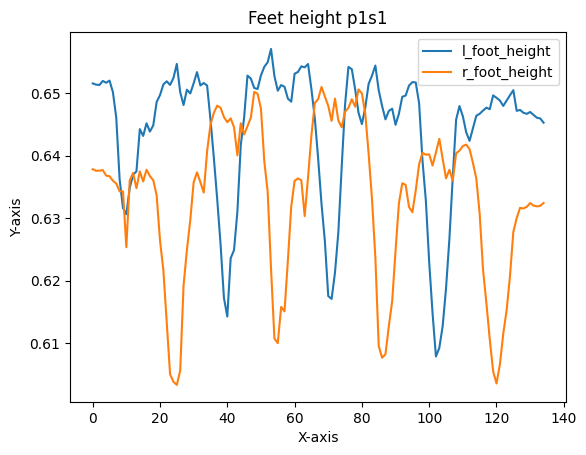

In [13]:
camera = 'c1'
sequence = 'p1s1'

frames = list(yolo_raw_dataset[sequence][camera].values())
l_foot_height = [frame[selected_joint_names_reversed['lfoot']][1] for frame in frames]
r_foot_height = [frame[selected_joint_names_reversed['rfoot']][1] for frame in frames]


plt.plot(range(len(l_foot_height)), l_foot_height, label='l_foot_height')
plt.plot(range(len(r_foot_height)), r_foot_height, label='r_foot_height')

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'Feet height {sequence}')
plt.legend()
plt.show()

In [14]:
from utils.gait_parameters_extractor_raw_2d import CoordinatesIdx2D, GaitParametersExtractorRaw2D

sequence = 'p1s1'
# camera = 'c1'
camera = 'c3'

gpe = GaitParametersExtractorRaw2D(
    sequence_parameters = yolo_raw_dataset[sequence][camera],
    selected_joints = selected_joint_names)


gait_params = gpe.get_gait_parameters()
gait_params.shape

(14, 135)

In [15]:
gait_params_names = gpe.get_gait_parameters_names()
gait_params_names

['legs_angles',
 'left_knee_angles',
 'right_knee_angles',
 'left_hip_angles',
 'right_hip_angles',
 'left_humerus_angles',
 'right_humerus_angles',
 'left_elbow_angles',
 'right_elbow_angles',
 'ankle_distances',
 'knee_distances',
 'elbow_distances',
 'hand_distances',
 'center_of_gravity_height_change']

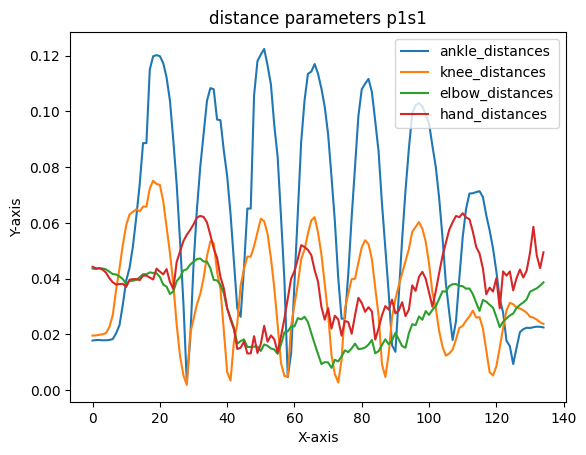

In [16]:
for name, params_value in zip(gait_params_names, gait_params): 
    if 'distance' in name:
        plt.plot(range(len(params_value)), params_value, label=name)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'distance parameters {sequence}')
plt.legend()
plt.show()

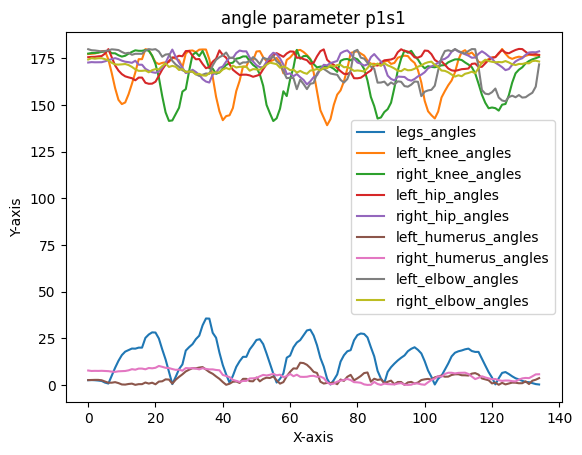

In [17]:
for name, params_value in zip(gait_params_names, gait_params): 
    if 'angle' in name:
        plt.plot(range(len(params_value)), params_value, label=name)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'angle parameter {sequence}')
plt.legend()
plt.show()

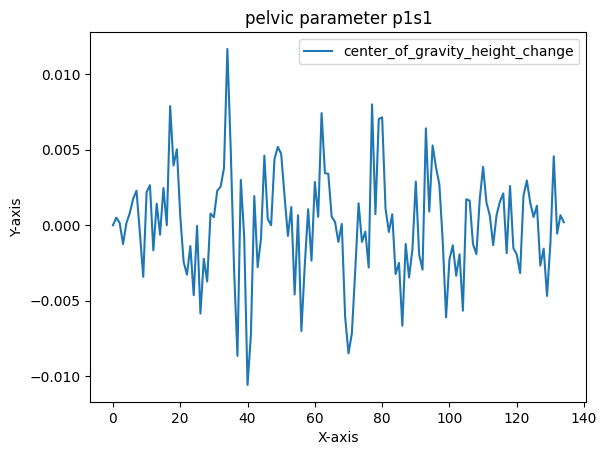

In [19]:
for name, params_value in zip(gait_params_names, gait_params): 
    if 'center' in name:
        plt.plot(range(len(params_value)), params_value, label=name)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'pelvic parameter {sequence}')
plt.legend()
plt.show()

In [20]:
np.array(gpe.get_gait_angles()).shape

(9, 135)

In [21]:
np.array(gpe.get_joint_distances()).shape

(4, 135)

In [22]:
np.array(gpe.get_pelvic_parameters()).shape

(1, 135)

In [23]:
gpe.get_step_frames()

([10, 40, 71, 103], [25, 55, 86, 120])

In [24]:
def _calc_step_frames(steps: list) -> list[int]:
    step_frames = []
    for i in range(len(steps)-1):
        step_frames.append(steps[i+1] - steps[i])
    return step_frames

def _fragment_step_frames(steps: list, window_size: int = 32) -> list[tuple[int, int]]:
    step_frames = []
    for i in range(len(steps)-1):
        center = steps[i] + (steps[i+1] - steps[i])//2
        start_frame = center - window_size//2
        end_frame = center + window_size//2
        step_frames.append((start_frame, end_frame))
    return step_frames

In [28]:
def separate_gait_sequences_to_cycles(data_2d, 
                                      selected_joint_names,
                                      camera: str = 'c1',
                                      window_size: int = 32,
                                      minima_window_size: int = 10,
                                      running_average_window_size: int = 1,
                                      coordinates_index: CoordinatesIdx2D = CoordinatesIdx2D(),
                                      print_stats: bool = True,
                                     ):
    results = {}
    cum_step_frames = []
    side = ''
    fail_counter = 0
    
    for seq_key in list(data_2d.keys()):
        gpe = GaitParametersExtractorRaw2D(
            sequence_parameters = data_2d[seq_key][camera],
            selected_joints = selected_joint_names,
            window_size = running_average_window_size,
        )

        l_steps, r_steps = gpe.get_step_frames(window_size = minima_window_size)
        
        if len(l_steps)>1 and len(r_steps)>1:
            steps_sequence = []
            if l_steps[0] < r_steps[0]:
                cum_step_frames += _calc_step_frames(l_steps)
                steps_sequence = _fragment_step_frames(l_steps, window_size)
                side = 'L'
            else:
                cum_step_frames += _calc_step_frames(r_steps)
                steps_sequence = _fragment_step_frames(r_steps, window_size)
                side = 'R'

            if print_stats:
                print(f"{seq_key} [{side}] - {steps_sequence}")
            for i, (start_frame, end_frame) in enumerate(steps_sequence):
                results[f"{seq_key}c{i}"] = {str(idx) : joints for idx, joints in enumerate(list(data_2d[seq_key][camera].values())[start_frame:end_frame])}
        else:
            fail_counter += 1

    if print_stats:
        print("   Steps: ", len(cum_step_frames))
        print("    Mean: ", sum(cum_step_frames)/len(cum_step_frames))
        print("     Max: ", max(cum_step_frames))
        print("     Min: ", min(cum_step_frames))
        print("  Median: ", sorted(cum_step_frames)[len(cum_step_frames)//2])
        print(" Over 32: ", sum(1 for step in cum_step_frames if step>32))
        print("  Failed: ", fail_counter)

    return results

In [29]:
results = separate_gait_sequences_to_cycles(
    data_2d = yolo_raw_dataset,
    selected_joint_names = selected_joint_names,
    minima_window_size = 10,
    camera = 'c1'
)

with open("./datasets/yolo/sequences_2d/steps_camera_1_yolo_v26.json", "w") as f:
    json.dump(results, f, indent=4)

First right step recognized as probably marked incorrectly and removed
p1s1 [L] - [(9, 41), (39, 71), (70, 102)]
Failed to find proper step frame keys
p1s3 [R] - [(20, 52), (49, 81), (81, 113)]
p1s4 [L] - [(14, 46), (45, 77)]
Failed to find proper step frame keys
p2s2 [L] - [(16, 48), (43, 75), (72, 104)]
p2s3 [R] - [(21, 53), (49, 81), (79, 111)]
Failed to find proper step frame keys
Failed to find proper step frame keys
p3s2 [L] - [(13, 45), (39, 71), (68, 100)]
Failed to find proper step frame keys
Failed to find proper step frame keys
p4s1 [L] - [(10, 42), (42, 74), (73, 105)]
First right step recognized as probably marked incorrectly and removed
p4s2 [L] - [(9, 41), (38, 70), (69, 101)]
p4s3 [R] - [(9, 41), (41, 73), (73, 105)]
p4s4 [L] - [(27, 59), (54, 86)]
p5s1 [L] - [(25, 57), (57, 89), (90, 122)]
p5s2 [R] - [(12, 44), (46, 78), (78, 110), (111, 143)]
Failed to find proper step frame keys
Failed to find proper step frame keys
p6s1 [R] - [(18, 50), (44, 76)]
p6s2 [L] - [(10, 42

In [33]:
results = separate_gait_sequences_to_cycles(
    data_2d = yolo_raw_dataset,
    selected_joint_names = selected_joint_names,
    minima_window_size = 14,
    camera = 'c3'
)

with open("./datasets/yolo/sequences_2d/steps_camera_3_yolo_v26.json", "w") as f:
    json.dump(results, f, indent=4)

p1s1 [R] - [(24, 56), (54, 86), (87, 119)]
Last left step recognized as probably marked incorrectly and removed
p1s2 [L] - [(18, 50)]
p1s3 [R] - [(19, 51), (49, 81), (80, 112)]
p1s4 [R] - [(21, 53), (51, 83)]
p2s1 [L] - [(25, 57), (53, 85), (84, 116)]
Failed to find proper step frame keys
p2s3 [R] - [(21, 53), (49, 81), (79, 111)]
Failed to find proper step frame keys
p3s1 [R] - [(22, 54), (51, 83), (82, 114)]
Failed to find proper step frame keys
p3s3 [R] - [(22, 54), (52, 84), (83, 115)]
p3s4 [L] - [(22, 54), (47, 79)]
p4s1 [R] - [(25, 57), (58, 90)]
Failed to find proper step frame keys
p4s3 [L] - [(24, 56), (56, 88)]
p4s4 [L] - [(22, 54), (52, 84)]
p5s1 [R] - [(13, 45), (41, 73), (74, 106), (107, 139)]
p5s2 [R] - [(50, 82), (112, 144)]
p5s3 [L] - [(27, 59), (60, 92), (93, 125)]
p5s4 [R] - [(45, 77), (76, 108)]
p6s1 [R] - [(17, 49), (44, 76)]
p6s2 [L] - [(30, 62), (67, 99)]
p6s3 [L] - [(18, 50), (46, 78), (74, 106)]
p6s4 [R] - [(20, 52), (46, 78)]
p7s1 [L] - [(22, 54), (49, 81), (76

In [34]:
results = separate_gait_sequences_to_cycles(
    data_2d = yolo_raw_dataset,
    selected_joint_names = selected_joint_names,
    minima_window_size = 14,
    camera = 'c1',
    running_average_window_size = 3,
)

with open("./datasets/yolo/sequences_2d/steps_camera_1_smoothed_yolo_v26.json", "w") as f:
    json.dump(results, f, indent=4)

p1s1 [R] - [(23, 55), (54, 86), (87, 119)]
p1s2 [R] - [(25, 57), (56, 88)]
p1s3 [R] - [(19, 51), (49, 81), (81, 113)]
Last left step recognized as probably marked incorrectly and removed
p1s4 [L] - [(14, 46)]
p2s1 [L] - [(25, 57), (54, 86), (84, 116)]
p2s2 [L] - [(16, 48), (43, 75), (72, 104)]
p2s3 [R] - [(21, 53), (50, 82), (79, 111)]
Failed to find proper step frame keys
p3s1 [R] - [(22, 54), (51, 83), (82, 114)]
p3s2 [L] - [(13, 45), (39, 71), (68, 100)]
p3s3 [R] - [(21, 53), (52, 84), (84, 116)]
Failed to find proper step frame keys
p4s1 [R] - [(26, 58), (58, 90)]
p4s2 [R] - [(23, 55), (53, 85)]
p4s3 [L] - [(25, 57), (56, 88)]
Failed to find proper step frame keys
p5s1 [L] - [(25, 57), (57, 89), (90, 122)]
p5s2 [L] - [(29, 61), (61, 93), (93, 125)]
p5s3 [L] - [(28, 60), (60, 92), (92, 124)]
Failed to find proper step frame keys
p6s1 [R] - [(17, 49), (44, 76)]
p6s2 [L] - [(10, 42), (36, 68), (63, 95)]
p6s3 [L] - [(19, 51), (46, 78), (74, 106)]
Failed to find proper step frame keys
p

In [35]:
results = separate_gait_sequences_to_cycles(
    data_2d = yolo_raw_dataset,
    selected_joint_names = selected_joint_names,
    minima_window_size = 14,
    camera = 'c3',
    running_average_window_size = 3,
)

with open("./datasets/yolo/sequences_2d/steps_camera_3_smoothed_yolo_v26.json", "w") as f:
    json.dump(results, f, indent=4)

p1s1 [R] - [(23, 55), (55, 87)]
Failed to find proper step frame keys
p1s3 [R] - [(19, 51), (49, 81), (80, 112)]
p1s4 [R] - [(21, 53), (51, 83)]
p2s1 [L] - [(24, 56), (54, 86), (84, 116)]
Failed to find proper step frame keys
p2s3 [R] - [(22, 54), (50, 82), (79, 111)]
Failed to find proper step frame keys
p3s1 [R] - [(22, 54), (52, 84), (82, 114)]
Failed to find proper step frame keys
p3s3 [R] - [(23, 55), (52, 84), (83, 115)]
p3s4 [L] - [(22, 54), (47, 79)]
p4s1 [R] - [(26, 58), (58, 90)]
Failed to find proper step frame keys
p4s3 [L] - [(25, 57), (57, 89)]
p4s4 [L] - [(22, 54), (53, 85)]
p5s1 [L] - [(25, 57), (57, 89), (90, 122)]
Failed to find proper step frame keys
p5s3 [L] - [(27, 59), (60, 92), (92, 124)]
p5s4 [L] - [(28, 60), (60, 92), (91, 123)]
p6s1 [R] - [(17, 49), (44, 76)]
Failed to find proper step frame keys
p6s3 [L] - [(18, 50), (46, 78), (74, 106)]
p6s4 [R] - [(20, 52), (46, 78)]
p7s1 [L] - [(22, 54), (49, 81), (76, 108)]
First left step recognized as probably marked in

In [36]:
results['p1s1c0']

{'0': [[0.20057043433189392, 0.24246732890605927],
  [0.20087319612503052, 0.23288531601428986],
  [0.1953325718641281, 0.2322775423526764],
  [0.1935351938009262, 0.23254179954528809],
  [0.17703475058078766, 0.23071962594985962],
  [0.19147992134094238, 0.28894877433776855],
  [0.16463983058929443, 0.2923983037471771],
  [0.18902049958705902, 0.36836808919906616],
  [0.156084805727005, 0.37856432795524597],
  [0.19030626118183136, 0.4281611740589142],
  [0.15873563289642334, 0.450675368309021],
  [0.19436220824718475, 0.4249347746372223],
  [0.1729762703180313, 0.4285838305950165],
  [0.2115533947944641, 0.5259512662887573],
  [0.16509921848773956, 0.5419617891311646],
  [0.21600304543972015, 0.628706157207489],
  [0.1145964190363884, 0.6067001223564148]],
 '1': [[0.20747964084148407, 0.23897585272789001],
  [0.20826970040798187, 0.22890017926692963],
  [0.20203329622745514, 0.2289368063211441],
  [0.2037106305360794, 0.2295621633529663],
  [0.18476253747940063, 0.22997832298278809],

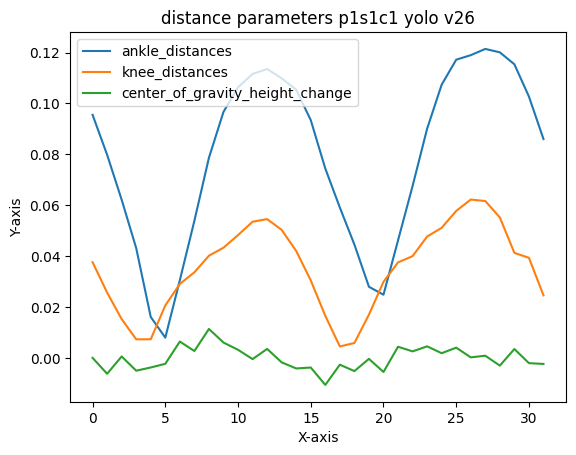

In [43]:
import json
import matplotlib.pyplot as plt
from utils.gait_parameters_extractor_raw_2d import CoordinatesIdx2D, GaitParametersExtractorRaw2D


with open("./datasets/yolo/sequences_2d/steps_camera_1_yolo_v26.json", "r") as file:
    yolo_2d_dataset = json.load(file)

with open("./datasets/yolo/selected_joint_names_v2.json", "r") as file:
    selected_joint_names = json.load(file)

gait_cycle = 'p1s1c1'

gpe = GaitParametersExtractorRaw2D(
    sequence_parameters = yolo_2d_dataset[gait_cycle],
    selected_joints = selected_joint_names
)

gait_params = gpe.get_gait_parameters()
gait_params_names = gpe.get_gait_parameters_names()

for name, params_value in zip(gait_params_names, gait_params): 
    if name in ['ankle_distances', 'knee_distances', 'center_of_gravity_height_change']:
        plt.plot(range(len(params_value)), params_value, label=name)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'distance parameters {gait_cycle} yolo v26')
plt.legend()
plt.show()

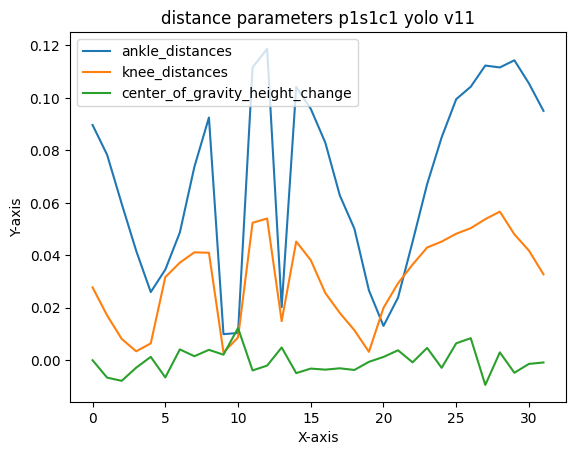

In [44]:
with open("./datasets/yolo/sequences_2d/steps_camera_1.json", "r") as file:
    yolo_2d_dataset = json.load(file)

with open("./datasets/yolo/selected_joint_names_v2.json", "r") as file:
    selected_joint_names = json.load(file)

gait_cycle = 'p1s1c1'

gpe = GaitParametersExtractorRaw2D(
    sequence_parameters = yolo_2d_dataset[gait_cycle],
    selected_joints = selected_joint_names
)

gait_params = gpe.get_gait_parameters()
gait_params_names = gpe.get_gait_parameters_names()

for name, params_value in zip(gait_params_names, gait_params): 
    if name in ['ankle_distances', 'knee_distances', 'center_of_gravity_height_change']:
        plt.plot(range(len(params_value)), params_value, label=name)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'distance parameters {gait_cycle} yolo v11')
plt.legend()
plt.show()

In [48]:
with open("./datasets/yolo/triangulation_yolo26.json", "r") as file:
    triangulation_data = json.load(file)

with open("./datasets/yolo/selected_joint_names_v2.json", "r") as file:
    selected_names = json.load(file)

scale_factor = 255
dataset_v3 = {key: [] for key in triangulation_data.keys()}
for key, sequence_data in triangulation_data.items():
    for frame in sequence_data:
        frame_parameters = {}
        for idx, joint_name in selected_names.items():
            frame_parameters[joint_name] = [num/scale_factor for num in frame[int(idx)]]
            
        dataset_v3[key].append(frame_parameters)

with open("./datasets/yolo/dataset_v3_yolo26.json", "w") as f:
    json.dump(dataset_v3, f, indent=4)